In [1]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pytorch_lightning as pl
import random
import logging
from torchvision import datasets, transforms

Regression on toy datasets

In [2]:
# Set the visual style for the plots
sns.set_style("white")

# Ratio of data reserved for testing (0.0 means all 20 points generated here are for training)
test_ratio = 0.0

# Granularity step, likely used later for plotting the confidence intervals smoothly
data_step = 0.005

# Standard deviation parameters for the Gaussian noise.
data_sigma= 3

# The core mathematical function: y = x^3 (exactly as described in Section 3.1 of the paper)
def func(x):
    return np.power(x, 3)

# Number of training data points (exactly 20, to simulate a scenario with sparse data)
num_data = 20

# Generate 20 random x-values uniformly distributed between -4 and 4.
# This represents our "In-Distribution" (known) territory.
data_x = np.random.uniform(-4, 4, size=num_data)

# Initialize the y-values array with zeros (this will hold the noisy training targets)
data_y = np.zeros(num_data)

# --- GROUND TRUTH DATA FOR PLOTTING ---
# We need a smooth, continuous line to draw the "true" underlying function on the graph
num_data_true = 1000

# Generate 1000 evenly spaced x-values from -6 to 6.
# This extra space (-6 to -4, and 4 to 6) is the "Out-Of-Distribution" (OOD) territory 
data_x_true = np.linspace(-6, 6, num_data_true)

# Initialize the ground truth y-values array
data_y_true = np.zeros(num_data_true)

In [3]:
# Loop through all 20 training data points
for i in range(num_data):
    # Apply homoscedastic (uniform) Gaussian noise across all data points.
    # The noise follows a Normal distribution with mean=0 and std_dev=data_sigma.
    # This matches the paper's exact specification of N(0, 3^2).
    data_y[i] = func(data_x[i]) + np.random.normal(0, data_sigma)
        
# --- GROUND TRUTH GENERATION ---
# Loop through the 1000 points for the continuous plotting axis
for i in range(num_data_true):
    # Compute the clean, underlying cubic function without any noise.
    # This serves as the "true" baseline to visualize the model's accuracy.
    data_y_true[i] = func(data_x_true[i])

In [4]:
# --- TRAIN/TEST SPLIT CALCULATION ---
# Calculate the exact number of training and testing samples based on the test_ratio.
# Since test_ratio was set to 0.0 earlier, num_train_data will be 20 and num_test_data will be 0.
num_train_data = int(num_data * (1 - test_ratio))
num_test_data  = num_data - num_train_data

# --- RESHAPING FOR NEURAL NETWORKS ---
# Neural networks in PyTorch (and models in Scikit-Learn) expect 2D arrays (matrices) 
# in the format [batch_size, num_features], even if there is only 1 feature. 
# We reshape the flat 1D arrays of shape (20,) into 2D column vectors of shape (20, 1).
data_x = np.reshape(data_x, [num_data, 1])
data_y = np.reshape(data_y, [num_data, 1])

# Reshape the ground truth arrays (1000 points) the same way: (1000,) -> (1000, 1)
data_y_true = np.reshape(data_y_true, [num_data_true, 1])
data_x_true = np.reshape(data_x_true, [num_data_true, 1])

# --- DATASET SLICING ---
# Slice the arrays to create the final training sets.
# Takes the first 'num_train_data' rows.
train_x = data_x[:num_train_data, :]
train_y = data_y[:num_train_data, :]

# Slice the arrays to create the testing sets.
# Takes the remaining rows (if test_ratio > 0). 
# With test_ratio=0.0, these will just be empty arrays.
test_x  = data_x[num_train_data:, :]
test_y  = data_y[num_train_data:, :]

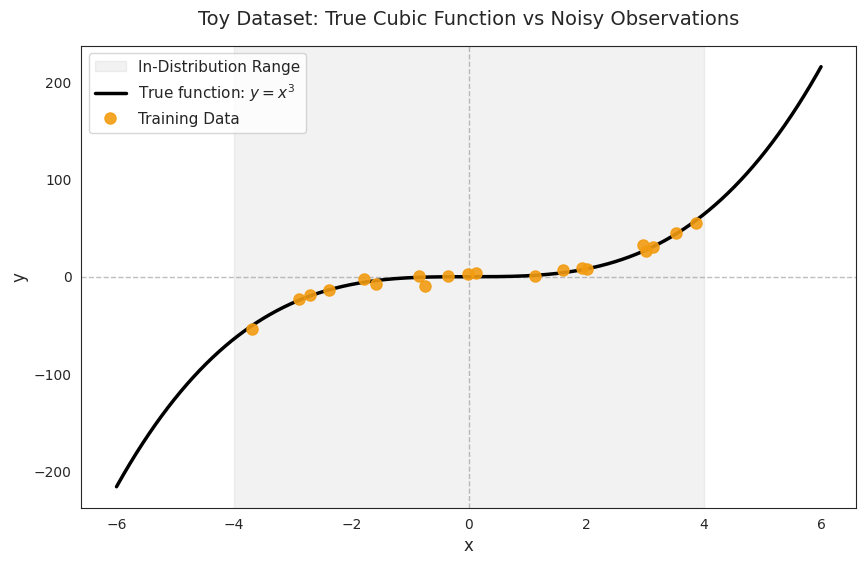

In [5]:
# --- ENHANCED VISUALIZATION OF THE TOY DATASET ---

# Set the figure size to be slightly wider
plt.rcParams['figure.figsize'] = [10, 6]

# Add subtle reference lines for the x and y axes (origin)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Visually highlight the "In-Distribution" area (-4 to 4) where training data exists.
plt.axvspan(-4, 4, color='gray', alpha=0.1, label='In-Distribution Range')

# Plot the ground truth continuous function (y = x^3)
plt.plot(data_x_true, data_y_true, color='black', linewidth=2.5, label='True function: $y=x^3$')

# Plot the noisy training data points
plt.plot(data_x, data_y, 'o', markersize=8, color='#F39C12', alpha=0.9, label='Training Data')

# Add axis labels and a clear title
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Toy Dataset: True Cubic Function vs Noisy Observations', fontsize=14, pad=15)

# Display the legend (loc='best' automatically finds the least cluttered corner)
plt.legend(loc='best', fontsize=11)

# Render the plot
plt.show()

In [6]:
# ==========================================
# BLOCK 1: FROM NUMPY TO PYTORCH
# ==========================================
# 1. Convert your NumPy arrays into PyTorch Tensors
# We use torch.Tensor() for direct conversion
x_train = torch.Tensor(train_x)
y_train = torch.Tensor(train_y)

# 2. Create the Dataset and the Dataloader
# Now we are using Tensors, so PyTorch won't throw an error anymore!
dataset = TensorDataset(x_train, y_train)
dataloader = DataLoader(dataset, batch_size=20, shuffle=True)

# 3. Convert the "true" data (the perfect curve for the plots)
# I am renaming your 'data_x_true' variables so that the plotting code (Block 5)
# finds them exactly as it expects them (x_test and y_test_true).
x_test = torch.Tensor(data_x_true)
y_test_true = torch.Tensor(data_y_true)

In [7]:
# ==========================================
# BLOCK 2: NEURAL NETWORK ARCHITECTURES
# ==========================================
print("Block 2: Defining Neural Network structures...")

# A. STANDARD NETWORK
# This network only predicts a single value (the Mean). It assumes homoscedastic 
# (constant) variance, which is a flaw for uncertainty estimation.
class StandardNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 100)
        self.fc2 = nn.Linear(100, 1) # Single output
        
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

# B. GAUSSIAN NETWORK (Deep Ensemble core architecture)
# This network predicts TWO values: Mean (mu) and Variance (var).
class GaussianNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 100)
        self.fc_mu = nn.Linear(100, 1)  # Output 1: Predicted value
        self.fc_var = nn.Linear(100, 1) # Output 2: Predicted uncertainty
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        # Variance must be strictly positive. 
        # Softplus enforces positivity, + 1e-6 prevents division by zero in NLL.
        var = F.softplus(self.fc_var(x)) + 1e-6
        return mu, var

print("Architectures ready!")

Block 2: Defining Neural Network structures...
Architectures ready!


In [8]:
# ==========================================
# BLOCK 3: PYTORCH LIGHTNING TRAINING LOGIC
# ==========================================
print("Block 3: Defining Training Logic (MSE, NLL, FGSM)...")

# A. Standard Training (MSE Loss)
class StandardLightning(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = StandardNet()
    def training_step(self, batch, batch_idx):
        x, y = batch
        # Standard Mean Squared Error
        return F.mse_loss(self.model(x), y)
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.1)

# B. Gaussian Training (NLL Loss - Equation 2 of the paper)
class GaussianLightning(pl.LightningModule):
    def __init__(self):
        super().__init__()
        self.model = GaussianNet()
    def training_step(self, batch, batch_idx):
        x, y = batch
        mu, var = self.model(x)
        # Custom Loss: The model learns to balance accuracy and uncertainty
        loss = 0.5 * torch.log(var) + 0.5 * ((y - mu)**2) / var
        return loss.mean()
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.1)

# C. Gaussian Training WITH ADVERSARIAL ATTACKS (FGSM)
class GaussianAdversarialLightning(pl.LightningModule):
    def __init__(self, epsilon=0.01):
        super().__init__()
        self.model = GaussianNet()
        self.epsilon = epsilon
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        # Enable gradient tracking for the input 'x' to craft the attack
        x.requires_grad = True
        
        # 1. Clean forward pass
        mu, var = self.model(x)
        loss = (0.5 * torch.log(var) + 0.5 * ((y - mu)**2) / var).mean()
        
        # 2. Craft Adversarial Example (FGSM)
        # Find the direction in the input space that maximizes the error
        gradients = torch.autograd.grad(outputs=loss, inputs=x, retain_graph=True, create_graph=False)[0]
        # Perturb the input data slightly in that direction
        x_adv = x + self.epsilon * gradients.sign()
        x_adv = x_adv.detach() # Stop gradient tracking for the fake data
        
        # 3. Adversarial forward pass
        mu_adv, var_adv = self.model(x_adv)
        loss_adv = (0.5 * torch.log(var_adv) + 0.5 * ((y - mu_adv)**2) / var_adv).mean()
        
        # 4. Total Loss (Minimize error on both clean and fake data)
        return loss + loss_adv
        
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.1)

print("Lightning Modules ready!")

Block 3: Defining Training Logic (MSE, NLL, FGSM)...
Lightning Modules ready!


In [9]:
# ==========================================
# BLOCK 4: EXECUTING THE TRAINING PHASES
# ==========================================
# Common settings to keep Kaggle output clean
trainer_kwargs = {"max_epochs": 400, "enable_progress_bar": False, "enable_model_summary": False, "logger": False}

dataset = TensorDataset(x_train, y_train)

dataloader = DataLoader(dataset, batch_size=20, shuffle=True)

print("Phase 1/4: Training 5 Standard Networks (MSE)...")
models_mse = []
for i in range(5):
    pl.seed_everything(i) # Crucial: Different seed = different initialization
    model = StandardLightning()
    pl.Trainer(**trainer_kwargs).fit(model, dataloader)
    models_mse.append(model)

print("Phase 2/4: Training 1 Gaussian Network (NLL)...")
pl.seed_everything(42)
model_nll = GaussianLightning()
pl.Trainer(**trainer_kwargs).fit(model_nll, dataloader)

print("Phase 3/4: Training 1 Gaussian Network (NLL + FGSM)...")
pl.seed_everything(42)
model_adv = GaussianAdversarialLightning()
pl.Trainer(**trainer_kwargs).fit(model_adv, dataloader)

print("Phase 4/4: Training 5 Gaussian Networks (NLL + FGSM)... (The Full Ensemble)")
models_ensemble = []
for i in range(5):
    pl.seed_everything(i)
    model = GaussianAdversarialLightning()
    pl.Trainer(**trainer_kwargs).fit(model, dataloader)
    models_ensemble.append(model)

print("\nAll models trained successfully!")

Seed set to 0
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Phase 1/4: Training 5 Standard Networks (MSE)...


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=400` reached.
Seed set to 1
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud loggin

Phase 2/4: Training 1 Gaussian Network (NLL)...


`Trainer.fit` stopped: `max_epochs=400` reached.
Seed set to 42
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Phase 3/4: Training 1 Gaussian Network (NLL + FGSM)...


`Trainer.fit` stopped: `max_epochs=400` reached.
Seed set to 0
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Phase 4/4: Training 5 Gaussian Networks (NLL + FGSM)... (The Full Ensemble)


`Trainer.fit` stopped: `max_epochs=400` reached.
Seed set to 1
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
`Trainer.fit` stopped: `max_epochs=400` reached.
Seed set to 2
Trainer will use only 1 of 2 GPUs b


All models trained successfully!


Block 5: Generating Final Figure 1...


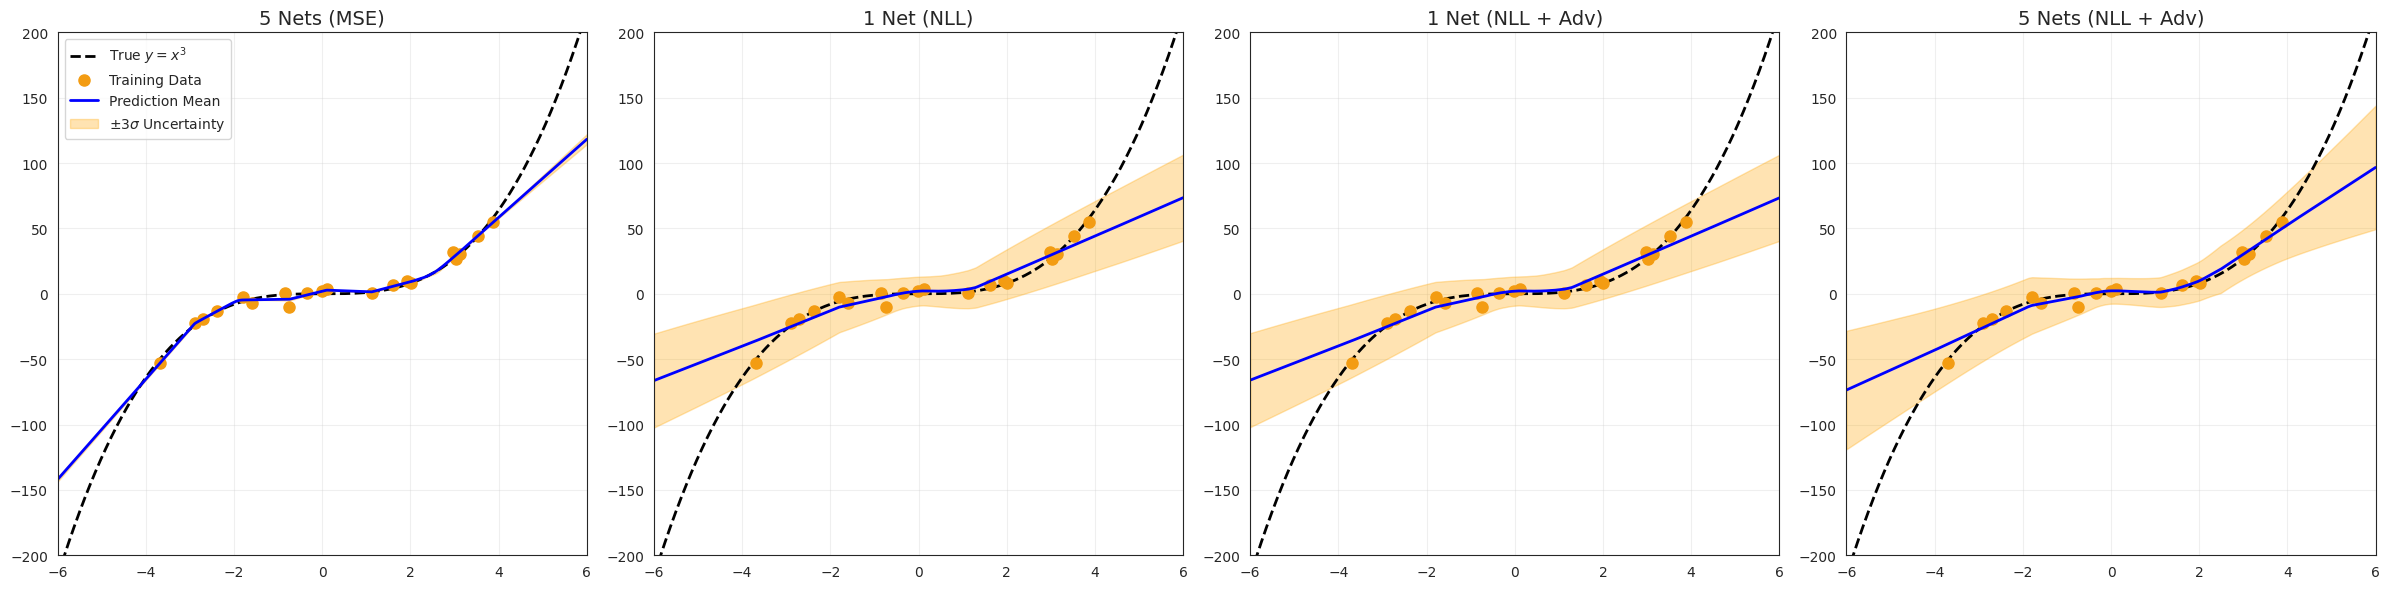

In [10]:
# ==========================================
# BLOCK 5: INFERENCE AND PAPER-STYLE PLOTTING
# ==========================================
print("Block 5: Generating Final Figure 1...")

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
titles = ["5 Nets (MSE)", "1 Net (NLL)", "1 Net (NLL + Adv)", "5 Nets (NLL + Adv)"]

with torch.no_grad():
    for ax, title, idx in zip(axes, titles, range(4)):
        # Plot Ground Truth and Training Data on all panels
        ax.plot(x_test.numpy(), y_test_true.numpy(), 'k--', linewidth=2, label="True $y=x^3$")
        ax.plot(x_train.numpy(), y_train.numpy(), 'o', color='#F39C12', markersize=8, label="Training Data")
        
        # --- Panel 1: MSE Ensemble ---
        if idx == 0:
            preds = torch.cat([m.model(x_test) for m in models_mse], dim=1)
            mean = preds.mean(dim=1).numpy()
            var = preds.var(dim=1).numpy() # Only captures Epistemic (model disagreement)
            
        # --- Panel 2: Single NLL ---
        elif idx == 1:
            mean, var = model_nll.model(x_test)
            mean, var = mean.squeeze().numpy(), var.squeeze().numpy()
            
        # --- Panel 3: Single NLL + FGSM ---
        elif idx == 2:
            mean, var = model_adv.model(x_test)
            mean, var = mean.squeeze().numpy(), var.squeeze().numpy()
            
        # --- Panel 4: Deep Ensemble (NLL + FGSM) ---
        elif idx == 3:
            means, vars = [], []
            for m in models_ensemble:
                m_, v_ = m.model(x_test)
                means.append(m_)
                vars.append(v_)
            
            # Combine predictions from all 5 models
            means = torch.cat(means, dim=1)
            vars = torch.cat(vars, dim=1)
            
            # Equation 5: Ensemble Mean
            mean = means.mean(dim=1).numpy()
            # Equation 5: Law of Total Variance (Aleatoric + Epistemic)
            var = (vars.mean(dim=1) + means.var(dim=1)).numpy()

        # Convert Variance to Standard Deviation (3 sigma for 99.7% confidence interval)
        std = np.sqrt(var) * 3
        
        # Draw the model's prediction and the uncertainty band
        ax.plot(x_test.numpy(), mean, 'b-', linewidth=2, label="Prediction Mean")
        ax.fill_between(x_test.squeeze().numpy(), mean - std, mean + std, color="orange", alpha=0.3, label=r"$\pm 3\sigma$ Uncertainty")
        
        # Aesthetics
        ax.set_title(title, fontsize=14)
        ax.set_xlim([-6, 6])
        ax.set_ylim([-200, 200])
        ax.grid(alpha=0.3)
        if idx == 0:
            ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

Regression on real world datasets (california_housing)

In [11]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [12]:
# ==========================================
# BLOCK 1: DATA LOADING AND PREPARATION
# ==========================================
print("Loading California Housing dataset...")
data = fetch_california_housing()

# X contains 8 features (e.g., house age, number of rooms, latitude, etc.)
# y contains the house value (in hundreds of thousands of dollars)
X = data.data
y = data.target

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SCALING: This step is optional for Random Forest, but ABSOLUTELY 
# FUNDAMENTAL for the neural networks we will use later. We standardize to mean 0 and variance 1.
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

Loading California Housing dataset...


In [13]:
# ==========================================
# BLOCK 2: RANDOM FOREST
# ==========================================
print("Training Random Forest (100 trees)...")
# We use 100 trees. n_jobs=-1 uses all available processor cores for faster training
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

# --- THE UNCERTAINTY TRICK FOR RANDOM FOREST ---
# Scikit-learn returns only the mean prediction by default. 
# To calculate the NLL, we must extract the predictions of ALL 100 TREES individually!
print("Extracting uncertainty (Tree variance)...")
tree_predictions = np.array([tree.predict(X_test_scaled) for tree in rf.estimators_])

# Now 'tree_predictions' is a [100, 4128] matrix. 
# We calculate the Mean and Variance along axis 0 (collapsing the 100 trees)
rf_mean = tree_predictions.mean(axis=0)
rf_variance = tree_predictions.var(axis=0)

# Mathematical safety: we prevent the variance from being exactly 0 (which would blow up the NLL)
rf_variance = np.clip(rf_variance, a_min=1e-6, a_max=None)

# --- EVALUATION (RMSE and NLL) ---
# Calculate RMSE (Root Mean Squared Error)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_mean))

# Calculate NLL (Negative Log-Likelihood)
# We use Equation 2 from the paper: log(var)/2 + (y - mean)^2 / (2*var)
rf_nll = np.mean(0.5 * np.log(rf_variance) + 0.5 * ((y_test - rf_mean)**2) / rf_variance)

print("\n--- RANDOM FOREST RESULTS ---")
print(f"RMSE: {rf_rmse:.4f} (Average error on house price)")
print(f"NLL:  {rf_nll:.4f} (Quality of uncertainty calibration)")

Training Random Forest (100 trees)...
Extracting uncertainty (Tree variance)...

--- RANDOM FOREST RESULTS ---
RMSE: 0.5051 (Average error on house price)
NLL:  -0.4562 (Quality of uncertainty calibration)


In [14]:
# ==========================================
# BLOCK 3: THE MC-DROPOUT MODEL ARCHITECTURE
# ==========================================
# --- PYTORCH DATA PREPARATION ---
# We use the scaled California Housing data created in the previous step
tensor_X_train = torch.Tensor(X_train_scaled)
tensor_y_train = torch.Tensor(y_train).view(-1, 1) # Reshape to [N, 1]
tensor_X_test = torch.Tensor(X_test_scaled)
tensor_y_test = torch.Tensor(y_test).view(-1, 1)

# Create Dataloaders for training
train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
# Batch size of 128 is standard for tabular data of this size
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# --- 4.  ---
class MCDropoutNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 100)
        # Here is the magic component: Dropout with 20% probability
        self.dropout1 = nn.Dropout(p=0.2) 
        self.fc2 = nn.Linear(100, 100)
        self.dropout2 = nn.Dropout(p=0.2)
        self.fc3 = nn.Linear(100, 1) # Outputs a single value (the price prediction)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# PyTorch Lightning Wrapper for training
class MCDropoutLightning(pl.LightningModule):
    def __init__(self, input_dim):
        super().__init__()
        self.model = MCDropoutNet(input_dim)
        self.loss_fn = nn.MSELoss() # Standard MSE loss for regression

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self.model(x)
        loss = self.loss_fn(y_hat, y)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.01)

# --- TRAINING THE MODEL ---
print("Training MC-Dropout Model...")
# Input dimension is 8 (number of features in California Housing)
mc_model = MCDropoutLightning(input_dim=8)
trainer = pl.Trainer(
    max_epochs=50, 
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    enable_progress_bar=False, # Keeping it clean
    enable_model_summary=False
)
trainer.fit(mc_model, train_loader)

# --- 4. THE MC-DROPOUT TRICK (INFERENCE) ---
print("Extracting Uncertainty (Monte Carlo Sampling)...")

# IMPORTANT: We explicitly call .train() instead of .eval() for testing!
# This forces the Dropout layers to remain ACTIVE during inference.
mc_model.model.train() 

num_samples = 50
mc_predictions = []

with torch.no_grad():
    # Pass the entire test set through the network 50 times
    for _ in range(num_samples):
        # The output will be slightly different each time due to active dropout
        preds = mc_model(tensor_X_test)
        mc_predictions.append(preds.numpy())

# mc_predictions is a list of 50 arrays, each of shape [4128, 1].
# We stack them to shape [50, 4128, 1] and squeeze to [50, 4128]
mc_predictions = np.stack(mc_predictions).squeeze()

# Calculate Mean and Variance across the 50 forward passes
mc_mean = mc_predictions.mean(axis=0)
mc_variance = mc_predictions.var(axis=0)

# Safety clip for NLL calculation
mc_variance = np.clip(mc_variance, a_min=1e-6, a_max=None)

# --- EVALUATION (RMSE and NLL) ---
# Calculate RMSE
mc_rmse = np.sqrt(mean_squared_error(y_test, mc_mean))

# Calculate NLL (Negative Log-Likelihood)
mc_nll = np.mean(0.5 * np.log(mc_variance) + 0.5 * ((y_test - mc_mean)**2) / mc_variance)

print("\n--- MC-DROPOUT RESULTS ---")
print(f"RMSE: {mc_rmse:.4f}")
print(f"NLL:  {mc_nll:.4f}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Training MC-Dropout Model...


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
2026-06-09 15:23:58.250754: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781018638.467342      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781018638.536708      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempti

Extracting Uncertainty (Monte Carlo Sampling)...

--- MC-DROPOUT RESULTS ---
RMSE: 0.5419
NLL:  3.6463


In [15]:
# ==========================================
# BLOCK 4: DEEP ENSEMBLE ARCHITECTURE (8 INPUTS)
# ==========================================

print("Block 4: Defining Gaussian Network for California Housing...")

class GaussianHousingNet(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        # Input layer takes the 8 features of the house
        self.fc1 = nn.Linear(input_dim, 100)
        # Extra hidden layer for tabular data complexity
        self.fc2 = nn.Linear(100, 100) 
        
        # Dual Output: The core of the Deep Ensemble paper
        self.fc_mu = nn.Linear(100, 1)  # Predicts the House Price
        self.fc_var = nn.Linear(100, 1) # Predicts the Uncertainty (Aleatoric)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        mu = self.fc_mu(x)
        # Variance must be positive. Softplus ensures this, 1e-6 prevents crashes.
        var = F.softplus(self.fc_var(x)) + 1e-6
        return mu, var

print("Architecture ready!")

Block 4: Defining Gaussian Network for California Housing...
Architecture ready!


In [16]:
# ==========================================
# BLOCK 5: TRAINING LOGIC WITH ADVERSARIAL ATTACKS
# ==========================================
print("Block 5: Defining Lightning Module with NLL and FGSM...")

class EnsembleHousingLightning(pl.LightningModule):
    # Epsilon is very small (0.01) because tabular data is sensitive to large perturbations
    def __init__(self, input_dim=8, epsilon=0.01):
        super().__init__()
        self.model = GaussianHousingNet(input_dim)
        self.epsilon = epsilon

    def training_step(self, batch, batch_idx):
        x, y = batch
        
        # Enable gradients for the input features to craft the FGSM attack
        x.requires_grad = True
        
        # --- 1. Clean Data Forward Pass ---
        mu, var = self.model(x)
        loss_clean = (0.5 * torch.log(var) + 0.5 * ((y - mu)**2) / var).mean()
        
        # --- 2. Generate Adversarial Data (FGSM) ---
        gradients = torch.autograd.grad(outputs=loss_clean, inputs=x, 
                                        retain_graph=True, create_graph=False)[0]
        # Push the house features slightly in the direction that maximizes error
        x_adv = x + self.epsilon * gradients.sign()
        x_adv = x_adv.detach()
        
        # --- 3. Adversarial Forward Pass ---
        mu_adv, var_adv = self.model(x_adv)
        loss_adv = (0.5 * torch.log(var_adv) + 0.5 * ((y - mu_adv)**2) / var_adv).mean()
        
        # --- 4. Total Loss ---
        # The model is penalized if it's overconfident on both clean and fake data
        return loss_clean + loss_adv

    def configure_optimizers(self):
        # Standard learning rate for tabular regression
        return torch.optim.Adam(self.parameters(), lr=0.01)

print("Lightning Module ready!")

Block 5: Defining Lightning Module with NLL and FGSM...
Lightning Module ready!


In [17]:
# ==========================================
# BLOCK 6: TRAINING THE 5 NETWORKS
# ==========================================
# Settings: 50 epochs is usually enough for this dataset.
trainer_kwargs = {
    "max_epochs": 50, 
    "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
    "enable_progress_bar": False, 
    "enable_model_summary": False, 
    "logger": False
}

print("Block 3: Training Deep Ensemble (5 Independent Networks)...")
ensemble_models = []
num_networks = 5

for i in range(num_networks):
    # Set different seed for distinct weight initialization
    pl.seed_everything(i * 100) 
    print(f"Training Network {i+1}/{num_networks}...")
    
    # Initialize and train the model
    model = EnsembleHousingLightning(input_dim=8)
    trainer = pl.Trainer(**trainer_kwargs)
    
    # NOTE: Assuming 'train_loader' is already in your environment from the MC Dropout step
    trainer.fit(model, train_loader)
    
    ensemble_models.append(model)

print("\nAll 5 networks trained successfully!")

Seed set to 0
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VIS

Block 3: Training Deep Ensemble (5 Independent Networks)...
Training Network 1/5...


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=50` reached.
Seed set to 100
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [

Training Network 2/5...


`Trainer.fit` stopped: `max_epochs=50` reached.
Seed set to 200
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


...

Training Network 4/5...


`Trainer.fit` stopped: `max_epochs=50` reached.
Seed set to 400
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Training Network 5/5...


`Trainer.fit` stopped: `max_epochs=50` reached.



All 5 networks trained successfully!


In [18]:
# ==========================================
# BLOCK 7: AGGREGATION AND FINAL EVALUATION
# ==========================================
print("Block 7: Extracting predictions and calculating final metrics...\n")

all_means = []
all_variances = []

with torch.no_grad():
    for model in ensemble_models:
        model.eval()
        # NOTE: Assuming 'tensor_X_test' is in memory from previous steps
        mu, var = model.model(tensor_X_test)
        
        all_means.append(mu.numpy())
        all_variances.append(var.numpy())

# Stack into arrays of shape [5, 4128, 1] and squeeze to [5, 4128]
all_means = np.stack(all_means).squeeze()
all_variances = np.stack(all_variances).squeeze()

# --- THE MAGIC FORMULA (Equation 5) ---
# 1. Final Price Prediction (Average of 5 networks)
ensemble_mean = all_means.mean(axis=0)

# 2. Final Total Uncertainty (Mean of Variances + Variance of Means)
ensemble_variance = all_variances.mean(axis=0) + all_means.var(axis=0)
# Prevent mathematical errors in log
ensemble_variance = np.clip(ensemble_variance, a_min=1e-6, a_max=None)


# --- FINAL METRICS CALCULATION ---
# y_test should be a flat numpy array for sklearn. If it's a tensor, use y_test.numpy()
y_test_np = y_test if isinstance(y_test, np.ndarray) else y_test.numpy().squeeze()

ensemble_rmse = np.sqrt(mean_squared_error(y_test_np, ensemble_mean))
ensemble_nll = np.mean(0.5 * np.log(ensemble_variance) + 0.5 * ((y_test_np - ensemble_mean)**2) / ensemble_variance)

print("=========================================")
print(f"RMSE: {ensemble_rmse:.4f} (Lower is better accuracy)")
print(f"NLL:  {ensemble_nll:.4f} (More negative is better uncertainty calibration)")
print("=========================================")

Block 7: Extracting predictions and calculating final metrics...

RMSE: 0.5169 (Lower is better accuracy)
NLL:  -0.4126 (More negative is better uncertainty calibration)


In [19]:
# ==========================================
# BLOCK 8: FINAL COMPARISON TABLE 
# ==========================================
import pandas as pd
from IPython.display import display

print("Generating Final Comparison Table...\n")

# Use the exact values you calculated
data = {
    "Model": [
        "1. Random Forest (100 trees)", 
        "2. MC Dropout (50 passes)", 
        "3. Deep Ensemble (5 Nets + FGSM)"
    ],
    "RMSE ↓ (Price Error)": [0.5051, 0.5419, 0.5169],
    "NLL ↓ (Uncertainty)": [-0.4562, 3.6463, -0.4126]
}

# Create the DataFrame and set the Model name as the index
df = pd.DataFrame(data).set_index("Model")

# --- APPLY VISUAL STYLING ---
# Green is better (lower), Red is worse (higher)
styled_df = df.style.format("{:.4f}").\
    background_gradient(subset=["RMSE ↓ (Price Error)"], cmap="RdYlGn_r").\
    background_gradient(subset=["NLL ↓ (Uncertainty)"], cmap="RdYlGn_r").\
    set_properties(**{
        'text-align': 'center', 
        'font-size': '14px', 
        'padding': '12px',
        'border': '1px solid #ddd'
    }).\
    set_table_styles([
        {'selector': 'th', 'props': [
            ('font-size', '14px'), 
            ('text-align', 'center'), 
            ('background-color', '#2c3e50'), 
            ('color', 'white'),
            ('padding', '12px')
        ]},
        {'selector': 'th.row_heading', 'props': [
            ('text-align', 'left'), 
            ('background-color', '#f8f9fa'), 
            ('color', '#2c3e50'),
            ('font-weight', 'bold')
        ]}
    ])

# Display the styled table
display(styled_df)

Generating Final Comparison Table...



,RMSE ↓ (Price Error),NLL ↓ (Uncertainty)
Model,,
1. Random Forest (100 trees),0.5051,-0.4562
2. MC Dropout (50 passes),0.5419,3.6463
3. Deep Ensemble (5 Nets + FGSM),0.5169,-0.4126


Classification on SVHN

In [20]:
# ==========================================
# BLOCK 1: IMPORT SVHN
# ==========================================

# Disable Lightning warnings for a cleaner notebook output
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

print("Block 1: Downloading and preparing SVHN dataset...")

# Define transformations: Convert images to PyTorch Tensors and Normalize them to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download SVHN Training and Test sets
# SVHN contains images of street view house numbers (0-9)
train_data = datasets.SVHN(root='./data', split='train', download=True, transform=transform)
test_data = datasets.SVHN(root='./data', split='test', download=True, transform=transform)

# Create DataLoaders to feed the data to the neural networks in batches
batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Successfully loaded {len(train_data)} training images.")
print(f"Successfully loaded {len(test_data)} test images.")
print("Data preparation complete! Ready for the next step.")

Block 1: Downloading and preparing SVHN dataset...


100%|██████████| 182M/182M [00:10<00:00, 17.1MB/s] 
100%|██████████| 64.3M/64.3M [00:04<00:00, 14.6MB/s]


Successfully loaded 73257 training images.
Successfully loaded 26032 test images.
Data preparation complete! Ready for the next step.


In [21]:
# ==========================================
# BLOCK 2: VGG-STYLE CONVOLUTIONAL NETWORK (3x3)
# ==========================================
print("Block 2: Defining VGG-style CNN Architecture...")

class VGG_SVHN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        
        # The Convolutional Feature Extractor
        self.features = nn.Sequential(
            # First Convolutional Block
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2), # Needed for the MC Dropout baseline
            
            # Second Convolutional Block
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.2)  # Needed for the MC Dropout baseline
        )
        
        # The Fully Connected Classifier
        self.classifier = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5), # Stronger Dropout for the dense layer
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        # Flatten the 2D feature maps into a 1D vector for the linear layers
        x = x.view(x.size(0), -1) 
        x = self.classifier(x)
        # Returns 10 raw scores (logits) corresponding to the 10 classes
        return x 

print("Architecture successfully defined!")

Block 2: Defining VGG-style CNN Architecture...
Architecture successfully defined!


In [22]:
# ==========================================
# BLOCK 3: CLASSIFICATION TRAINING LOGIC 
# ==========================================
import torch
import torch.nn as nn
import pytorch_lightning as pl

print("Block 3: Defining Standard, Adversarial, and Random Noise Modules...")

# A. STANDARD TRAINING 
class StandardClassificationLightning(pl.LightningModule):
    def __init__(self, learning_rate=0.001):
        super().__init__()
        self.model = VGG_SVHN(num_classes=10)
        self.learning_rate = learning_rate
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self.model(x)
        loss = self.criterion(logits, y)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)


# B. ADVERSARIAL TRAINING (Ensemble + AT)
class AdversarialClassificationLightning(pl.LightningModule):
    def __init__(self, learning_rate=0.001, epsilon=0.01):
        super().__init__()
        self.model = VGG_SVHN(num_classes=10)
        self.learning_rate = learning_rate
        self.epsilon = epsilon
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x.requires_grad = True

        logits_clean = self.model(x)
        loss_clean = self.criterion(logits_clean, y)

        gradients = torch.autograd.grad(outputs=loss_clean, inputs=x, 
                                        retain_graph=True, create_graph=False)[0]
        
        x_adv = x + self.epsilon * gradients.sign()
        x_adv = x_adv.detach() 

        logits_adv = self.model(x_adv)
        loss_adv = self.criterion(logits_adv, y)

        return loss_clean + loss_adv

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)


# C. RANDOM NOISE TRAINING (Ensemble + R)
class RandomNoiseClassificationLightning(pl.LightningModule):
    def __init__(self, learning_rate=0.001, noise_std=0.01):
        super().__init__()
        self.model = VGG_SVHN(num_classes=10)
        self.learning_rate = learning_rate
        self.noise_std = noise_std
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch

        # 1. Standard Forward Pass on Clean Data
        logits_clean = self.model(x)
        loss_clean = self.criterion(logits_clean, y)

        # 2. Add Random Gaussian Noise
        noise = torch.randn_like(x) * self.noise_std
        x_noisy = x + noise

        # 3. Noisy Forward Pass
        logits_noisy = self.model(x_noisy)
        loss_noisy = self.criterion(logits_noisy, y)

        # 4. Total Loss
        return loss_clean + loss_noisy

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate)

print("All 3 Lightning Modules successfully defined!")

Block 3: Defining Standard, Adversarial, and Random Noise Modules...
All 3 Lightning Modules successfully defined!


In [23]:
# ==========================================
# BLOCK 4: TRAINING ALL ENSEMBLES (SVHN)
# ==========================================
print("Block 4: Starting the Training Phase for all variants...")

num_nets = 5 
epochs = 10 

trainer_kwargs = {
    "max_epochs": epochs, 
    "accelerator": "gpu" if torch.cuda.is_available() else "cpu",
    "enable_progress_bar": False, # Disabled to keep the Kaggle output perfectly clean
    "enable_model_summary": False,
    "logger": False
}

# 1. Train Standard Networks (Ensemble / MC Dropout)
print("1/3 --- Training Standard Networks ---")
standard_models = []
for i in range(num_nets):
    pl.seed_everything(i * 42)
    model = StandardClassificationLightning()
    pl.Trainer(**trainer_kwargs).fit(model, train_loader)
    standard_models.append(model)

# 2. Train Random Noise Networks (Ensemble + R)
print("2/3 --- Training Random Noise Networks (Ensemble + R) ---")
random_models = []
for i in range(num_nets):
    pl.seed_everything(i * 42)
    model = RandomNoiseClassificationLightning()
    pl.Trainer(**trainer_kwargs).fit(model, train_loader)
    random_models.append(model)

# 3. Train Adversarial Networks (Ensemble + AT)
print("3/3 --- Training Adversarial Networks (Ensemble + AT) ---")
adversarial_models = []
for i in range(num_nets):
    pl.seed_everything(i * 42)
    model = AdversarialClassificationLightning()
    pl.Trainer(**trainer_kwargs).fit(model, train_loader)
    adversarial_models.append(model)

print("\nAll 15 models successfully trained!")

Seed set to 0


Block 4: Starting the Training Phase for all variants...
1/3 --- Training Standard Networks ---


/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/checkpoints exists and is not empty.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
Seed set to 42
Seed set to 84
Seed set to 126
Seed set to 168
Seed set to 0


2/3 --- Training Random Noise Networks (Ensemble + R) ---


Seed set to 42
Seed set to 84
Seed set to 126
Seed set to 168
Seed set to 0


3/3 --- Training Adversarial Networks (Ensemble + AT) ---


Seed set to 42
Seed set to 84
Seed set to 126
Seed set to 168



All 15 models successfully trained!


Block 5: Evaluating models on SVHN Test Set...
Calculating metrics...
Generating Plots...


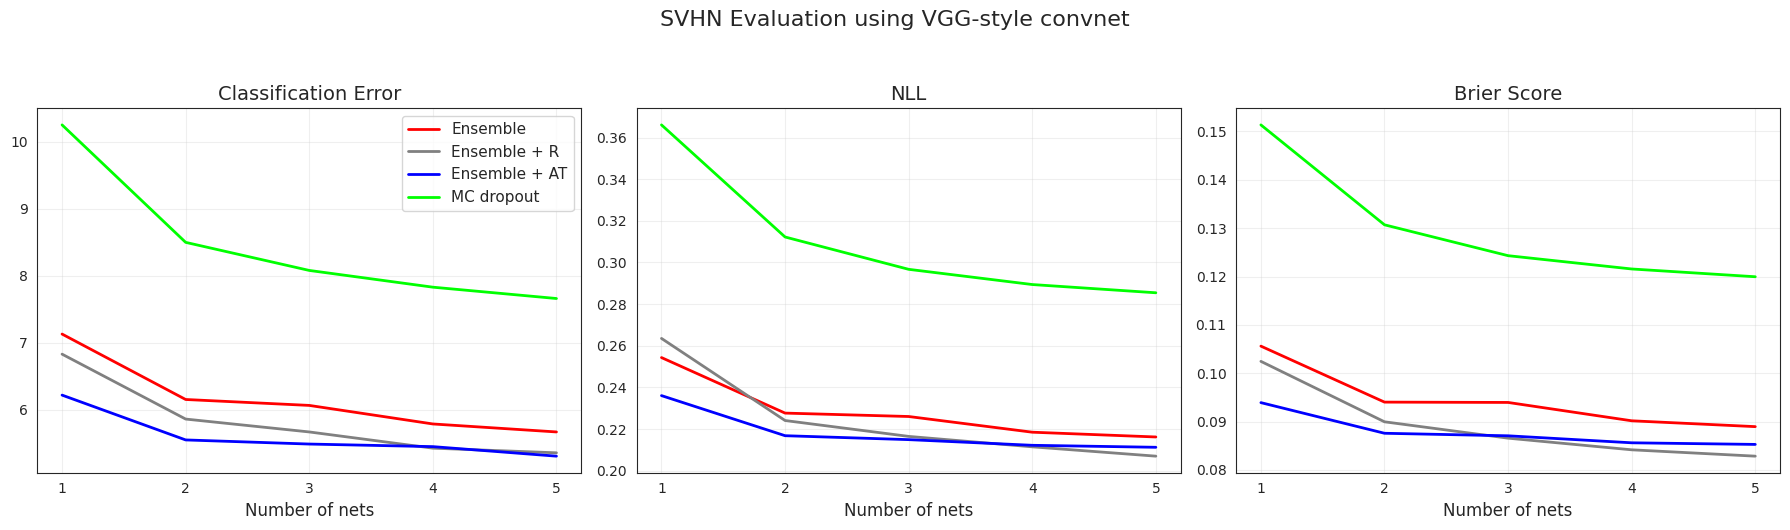

In [24]:
# ==========================================
# BLOCK 5: EVALUATION AND PAPER FIGURES (SVHN)
# ==========================================

print("Block 5: Evaluating models on SVHN Test Set...")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

true_labels = []
for _, y in test_loader:
    true_labels.append(y)
true_labels = torch.cat(true_labels)
num_samples = len(true_labels)
num_classes = 10

def get_predictions(models_list, loader, device, is_mc_dropout=False):
    all_probs = []
    for model in models_list:
        model = model.to(device)
        if is_mc_dropout:
            model.train() # Keep Dropout layers ACTIVE
        else:
            model.eval()  # DEACTIVATE Dropout for standard inference
            
        probs = []
        with torch.no_grad():
            for x, _ in loader:
                x = x.to(device)
                logits = model(x)
                probs.append(F.softmax(logits, dim=1).cpu())
        all_probs.append(torch.cat(probs, dim=0))
    return torch.stack(all_probs)

print("Collecting Standard Ensemble predictions...")
probs_ensemble = get_predictions(standard_models, test_loader, device, is_mc_dropout=False)

print("Collecting Random Noise Ensemble (Ensemble + R) predictions...")
probs_r = get_predictions(random_models, test_loader, device, is_mc_dropout=False)

print("Collecting Adversarial Ensemble (Ensemble + AT) predictions...")
probs_at = get_predictions(adversarial_models, test_loader, device, is_mc_dropout=False)

print("Collecting MC Dropout predictions (5 passes)...")
mc_dropout_models = [standard_models[0]] * 5 
probs_mc = get_predictions(mc_dropout_models, test_loader, device, is_mc_dropout=True)

def calculate_metrics(probs_stack, labels):
    M = probs_stack.size(0)
    errors, nlls, briers = [], [], []
    labels_onehot = F.one_hot(labels, num_classes=num_classes).float()
    
    for m in range(1, M + 1):
        mean_probs = probs_stack[:m].mean(dim=0)
        
        preds = mean_probs.argmax(dim=1)
        error = (preds != labels).float().mean().item() * 100
        
        eps = 1e-12 
        nll = -torch.log(mean_probs[torch.arange(num_samples), labels] + eps).mean().item()
        brier = ((mean_probs - labels_onehot) ** 2).sum(dim=1).mean().item()
        
        errors.append(error)
        nlls.append(nll)
        briers.append(brier)
        
    return errors, nlls, briers

print("Calculating metrics...")
err_ens, nll_ens, brier_ens = calculate_metrics(probs_ensemble, true_labels)
err_r, nll_r, brier_r       = calculate_metrics(probs_r, true_labels)
err_at, nll_at, brier_at    = calculate_metrics(probs_at, true_labels)
err_mc, nll_mc, brier_mc    = calculate_metrics(probs_mc, true_labels)

# --- PLOTTING ---
print("Generating Plots...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x_axis = list(range(1, 6))

metrics = [
    ("Classification Error", err_ens, err_r, err_at, err_mc),
    ("NLL", nll_ens, nll_r, nll_at, nll_mc),
    ("Brier Score", brier_ens, brier_r, brier_at, brier_mc)
]

for idx, (title, y_ens, y_r, y_at, y_mc) in enumerate(metrics):
    ax = axes[idx]
    
    # Exact colors from the paper
    ax.plot(x_axis, y_ens, 'r-', label='Ensemble', linewidth=2)
    ax.plot(x_axis, y_r, color='gray', label='Ensemble + R', linewidth=2)
    ax.plot(x_axis, y_at, 'b-', label='Ensemble + AT', linewidth=2)
    ax.plot(x_axis, y_mc, color='lime', label='MC dropout', linewidth=2)
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Number of nets", fontsize=12)
    ax.set_xticks(x_axis)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=11)

plt.suptitle("SVHN Evaluation using VGG-style convnet", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

SVHN with OOD data (CIFAR-10)

In [25]:
# ==========================================
# BLOCK 6: IMPORT AND PREDICT CIFAR-10
# ==========================================

print("Block 6: Downloading CIFAR-10 (OOD Dataset)...")

# CRITICAL: We must use the exact same transformations used for SVHN
# so the network receives the image format it expects.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Download CIFAR-10 Test Data
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
cifar_loader = DataLoader(cifar_test, batch_size=128, shuffle=False, num_workers=2)

print(f"Loaded {len(cifar_test)} OOD images. Starting predictions...\n")

# Reuse the get_predictions function from Block 5
print("1/4 Collecting Standard Ensemble predictions on CIFAR-10...")
probs_ensemble_ood = get_predictions(standard_models, cifar_loader, device, is_mc_dropout=False)

print("2/4 Collecting Ensemble + R predictions on CIFAR-10...")
probs_r_ood = get_predictions(random_models, cifar_loader, device, is_mc_dropout=False)

print("3/4 Collecting Ensemble + AT predictions on CIFAR-10...")
probs_at_ood = get_predictions(adversarial_models, cifar_loader, device, is_mc_dropout=False)

print("4/4 Collecting MC Dropout predictions on CIFAR-10...")
probs_mc_ood = get_predictions(mc_dropout_models, cifar_loader, device, is_mc_dropout=True)

print("\nOOD Predictions complete! Ready for plotting.")

Block 6: Downloading CIFAR-10 (OOD Dataset)...


100%|██████████| 170M/170M [00:02<00:00, 69.9MB/s] 


Loaded 10000 OOD images. Starting predictions...

1/4 Collecting Standard Ensemble predictions on CIFAR-10...
2/4 Collecting Ensemble + R predictions on CIFAR-10...
3/4 Collecting Ensemble + AT predictions on CIFAR-10...
4/4 Collecting MC Dropout predictions on CIFAR-10...

OOD Predictions complete! Ready for plotting.


Block 7: Calculating Entropy and generating Paper Figures...


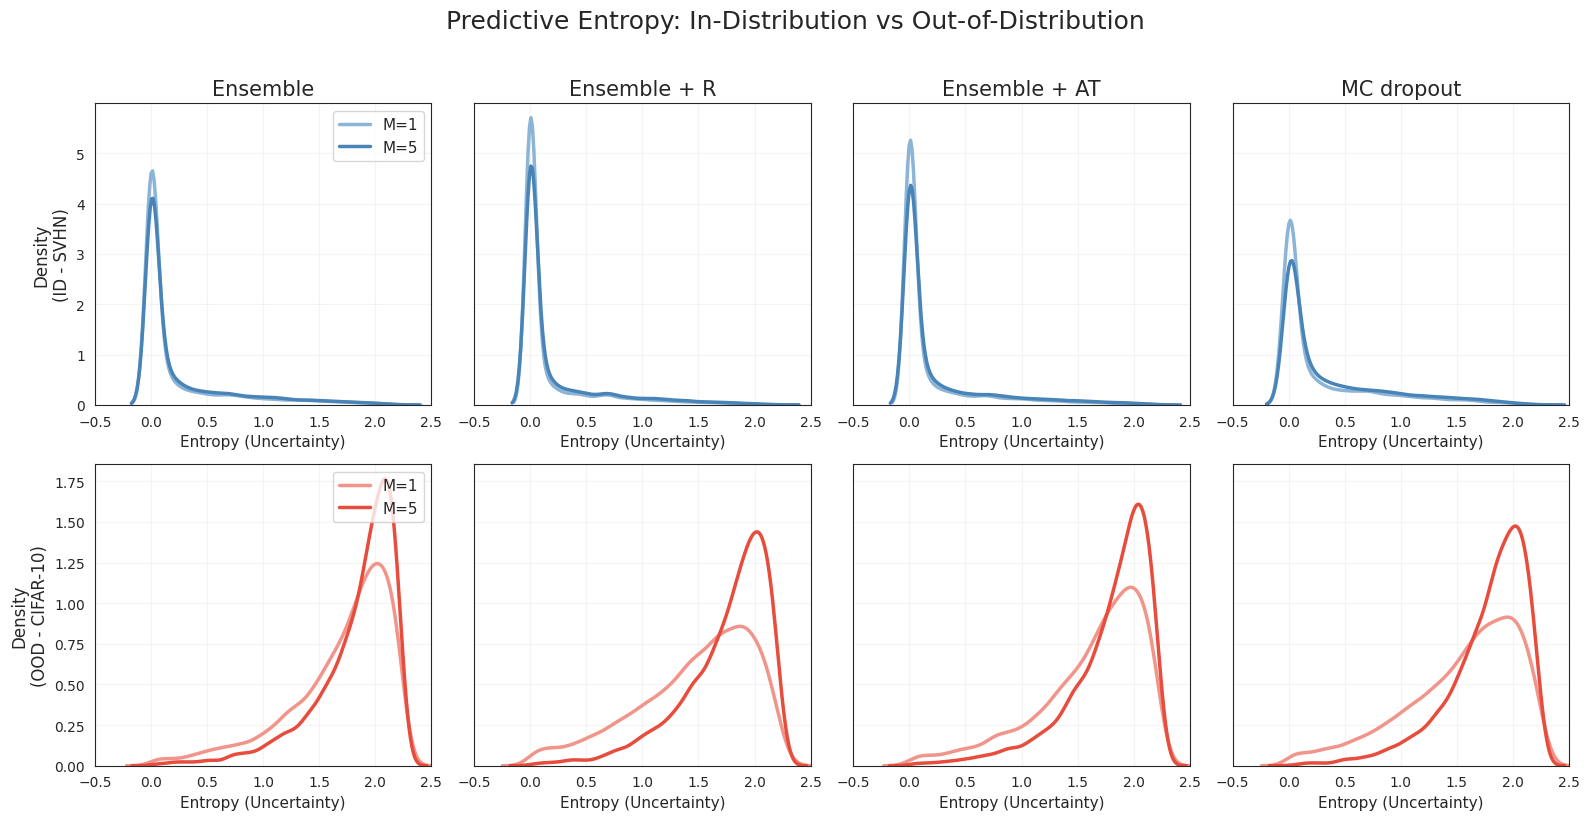

In [26]:
# ==========================================
# BLOCK 7: ENTROPY HISTOGRAMS (IN vs OOD)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import torch

print("Block 7: Calculating Entropy and generating Paper Figures...")

# Entropy Calculation Function
def get_entropy(probs_stack, M):
    """Calculates the predictive entropy of the ensemble up to M networks."""
    # probs_stack shape: [num_models, num_samples, num_classes]
    mean_probs = probs_stack[:M].mean(dim=0)
    
    eps = 1e-12 # Prevent log(0)
    # Entropy Formula: H = - sum( p * log(p) )
    entropy = -torch.sum(mean_probs * torch.log(mean_probs + eps), dim=1)
    return entropy.numpy()

# Dynamically decide which 'M' values to plot based on how many models you trained
max_nets = len(standard_models)
M_values = sorted(list(set([1, 5, max_nets])))

# Initialize the 2x4 Grid (Removed sharex=True to show X-axis on top row, increased height to 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey='row')

# Group the probabilities we extracted in Block 5 (In-Dist) and Block 6 (OOD)
models_probs_in = [probs_ensemble, probs_r, probs_at, probs_mc]
models_probs_ood = [probs_ensemble_ood, probs_r_ood, probs_at_ood, probs_mc_ood]
titles = ["Ensemble", "Ensemble + R", "Ensemble + AT", "MC dropout"]

# Color palettes to mimic the paper's specific shades (light to dark)
blue_shades = ['#8CB4D6', '#4984B8', '#154360']
red_shades  = ['#F1948A', '#E74C3C', '#7B241C']

# Loop through the 4 methods
for col in range(4):
    ax_in = axes[0, col]
    ax_ood = axes[1, col]
    
    # Standard font weight for titles
    ax_in.set_title(titles[col], fontsize=15)
    
    for idx, M in enumerate(M_values):
        color_idx = min(idx, 2) # Ensure we don't go out of color bounds
        
        # Top Row: In-Distribution (SVHN) -> Blue Curves
        ent_in = get_entropy(models_probs_in[col], M)
        sns.kdeplot(ent_in, ax=ax_in, label=f"M={M}", color=blue_shades[color_idx], linewidth=2.5)
        
        # Bottom Row: Out-of-Distribution (CIFAR-10) -> Red/Orange Curves
        ent_ood = get_entropy(models_probs_ood[col], M)
        sns.kdeplot(ent_ood, ax=ax_ood, label=f"M={M}", color=red_shades[color_idx], linewidth=2.5)

    # Formatting X axes for BOTH rows now
    ax_in.set_xlim(-0.5, 2.5)
    ax_ood.set_xlim(-0.5, 2.5)
    ax_in.set_xlabel("Entropy (Uncertainty)", fontsize=11)
    ax_ood.set_xlabel("Entropy (Uncertainty)", fontsize=11)
    
    # Formatting Y axes with standard font weight
    if col == 0:
        ax_in.set_ylabel("Density\n(ID - SVHN)", fontsize=12)
        ax_ood.set_ylabel("Density\n(OOD - CIFAR-10)", fontsize=12)
    else:
        ax_in.set_ylabel("Density", fontsize=11)
        ax_ood.set_ylabel("Density", fontsize=11)
    
    # Add grid for better readability
    ax_in.grid(alpha=0.2)
    ax_ood.grid(alpha=0.2)
    
    if col == 0:
        ax_in.legend(fontsize=11, loc='upper right')
        ax_ood.legend(fontsize=11, loc='upper right')

# Standard font weight for the main title, slightly lowered to avoid cutting off
plt.suptitle("Predictive Entropy: In-Distribution vs Out-of-Distribution", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

Block 8: Running MC Dropout Stress Test...

--- Testing Dropout Rate: 5% ---
Extracting SVHN predictions...
Extracting CIFAR-10 predictions...

--- Testing Dropout Rate: 20% ---
Extracting SVHN predictions...
Extracting CIFAR-10 predictions...

--- Testing Dropout Rate: 50% ---
Extracting SVHN predictions...
Extracting CIFAR-10 predictions...

Generating Stress Test Plot...


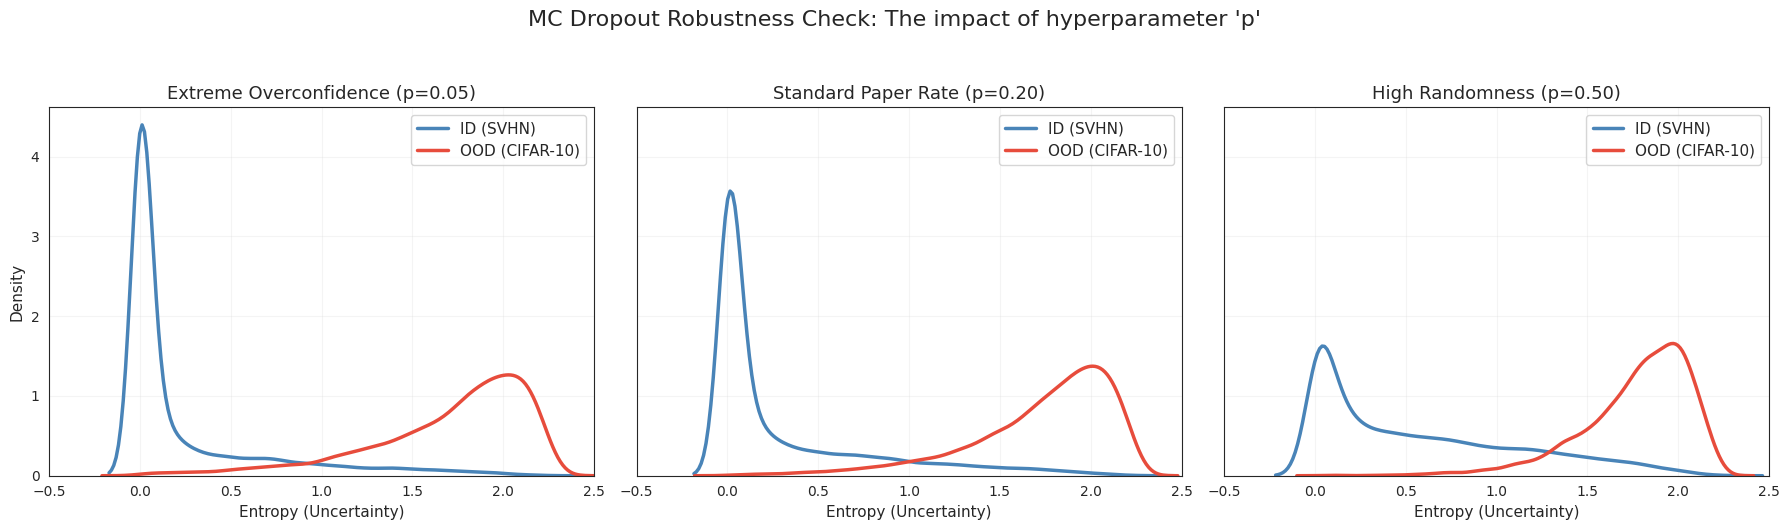

In [27]:
# ==========================================
# BLOCK 8: MC DROPOUT STRESS TEST
# ==========================================

print("Block 8: Running MC Dropout Stress Test...")

# 1. Helper Function to dynamically change the Dropout rate inside the model
def set_dropout_rate(model, p_value):
    """Iterates through all layers and changes the dropout probability."""
    for module in model.modules():
        if isinstance(module, nn.Dropout):
            module.p = p_value

# We will test 3 scenarios: Extreme Overconfidence (5%), Standard (20%), Extreme Randomness (50%)
test_rates = [0.05, 0.20, 0.50]
results_in = []
results_ood = []

# The model we use for MC Dropout is the first standard model
base_model = standard_models[0]
mc_models_list = [base_model] * 5 # 5 forward passes

for rate in test_rates:
    print(f"\n--- Testing Dropout Rate: {rate*100:.0f}% ---")
    
    # Inject the new dropout rate into the model
    set_dropout_rate(base_model, rate)
    
    # Collect predictions for In-Distribution (SVHN)
    print("Extracting SVHN predictions...")
    probs_in = get_predictions(mc_models_list, test_loader, device, is_mc_dropout=True)
    ent_in = get_entropy(probs_in, 5) # M = 5 passes
    results_in.append(ent_in)
    
    # Collect predictions for Out-of-Distribution (CIFAR-10)
    print("Extracting CIFAR-10 predictions...")
    probs_ood = get_predictions(mc_models_list, cifar_loader, device, is_mc_dropout=True)
    ent_ood = get_entropy(probs_ood, 5) # M = 5 passes
    results_ood.append(ent_ood)

# Restore the original dropout rate just to be clean
set_dropout_rate(base_model, 0.20)

# 2. Plotting the Stress Test Results
print("\nGenerating Stress Test Plot...")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

titles = ["Extreme Overconfidence (p=0.05)", "Standard Paper Rate (p=0.20)", "High Randomness (p=0.50)"]

for idx, rate in enumerate(test_rates):
    ax = axes[idx]
    
    # Blue curve for ID (SVHN)
    sns.kdeplot(results_in[idx], ax=ax, color='#4984B8', linewidth=2.5, label='ID (SVHN)')
    
    # Red curve for OOD (CIFAR-10)
    sns.kdeplot(results_ood[idx], ax=ax, color='#E74C3C', linewidth=2.5, label='OOD (CIFAR-10)')
    
    ax.set_title(titles[idx], fontsize=13)
    ax.set_xlim(-0.5, 2.5)
    ax.set_xlabel("Entropy (Uncertainty)", fontsize=11)
    if idx == 0:
        ax.set_ylabel("Density", fontsize=11)
    else:
        ax.set_ylabel("")
        
    ax.legend(fontsize=11)
    ax.grid(alpha=0.2)

plt.suptitle("MC Dropout Robustness Check: The impact of hyperparameter 'p'", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Block 9: Calculating Accuracy vs Confidence...


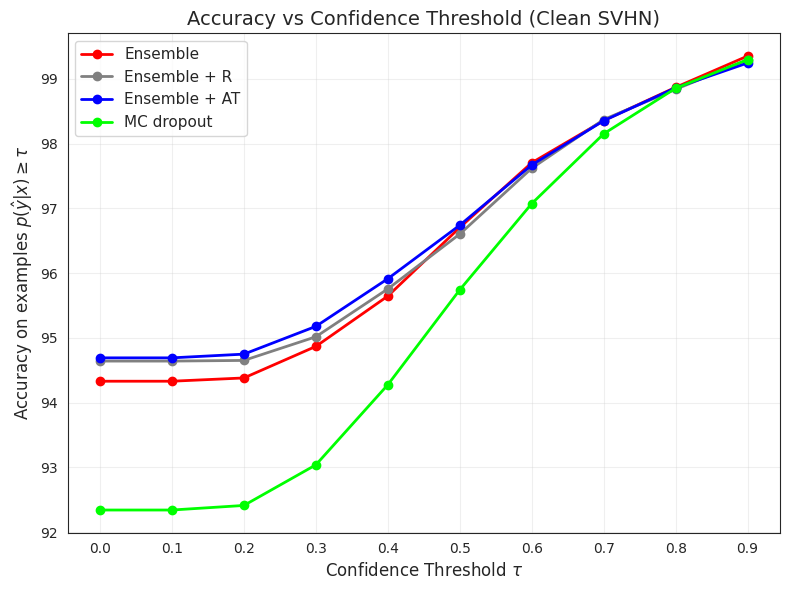

In [28]:
# ==========================================
# BLOCK 9: ACCURACY VS CONFIDENCE (SVHN Clean)
# ==========================================

print("Block 9: Calculating Accuracy vs Confidence...")

# Define the confidence thresholds (tau) from 0.0 to 0.95
tau_values = np.arange(0.0, 1.0, 0.1)

# A helper function to calculate accuracy for predictions above threshold tau
def calc_acc_vs_conf(probs_stack, labels, tau_list, M=5):
    # Get the average probability of the M networks
    mean_probs = probs_stack[:M].mean(dim=0)
    
    # Extract the confidence (max probability) and the predicted class
    confidences, predictions = mean_probs.max(dim=1)
    
    accuracies = []
    for tau in tau_list:
        # Keep only the predictions where confidence is >= tau
        mask = confidences >= tau
        
        # If no samples meet the threshold, accuracy is NaN (avoid division by zero)
        if mask.sum() == 0:
            accuracies.append(np.nan)
        else:
            # Calculate accuracy only on the confident predictions
            correct = (predictions[mask] == labels[mask]).float().sum().item()
            total = mask.sum().item()
            accuracies.append((correct / total) * 100)
            
    return accuracies

# Calculate for the 4 methods
acc_ens = calc_acc_vs_conf(probs_ensemble, true_labels, tau_values)
acc_r   = calc_acc_vs_conf(probs_r, true_labels, tau_values)
acc_at  = calc_acc_vs_conf(probs_at, true_labels, tau_values)
acc_mc  = calc_acc_vs_conf(probs_mc, true_labels, tau_values)

# Plotting the results
plt.figure(figsize=(8, 6))

plt.plot(tau_values, acc_ens, 'r-o', label='Ensemble', linewidth=2)
plt.plot(tau_values, acc_r, color='gray', marker='o', linestyle='-', label='Ensemble + R', linewidth=2)
plt.plot(tau_values, acc_at, 'b-o', label='Ensemble + AT', linewidth=2)
plt.plot(tau_values, acc_mc, color='lime', marker='o', linestyle='-', label='MC dropout', linewidth=2)

plt.title("Accuracy vs Confidence Threshold (Clean SVHN)", fontsize=14)
plt.xlabel(r"Confidence Threshold $\tau$", fontsize=12)
plt.ylabel(r"Accuracy on examples $p(\hat{y}|x) \geq \tau$", fontsize=12)
plt.xticks(tau_values)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()